      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


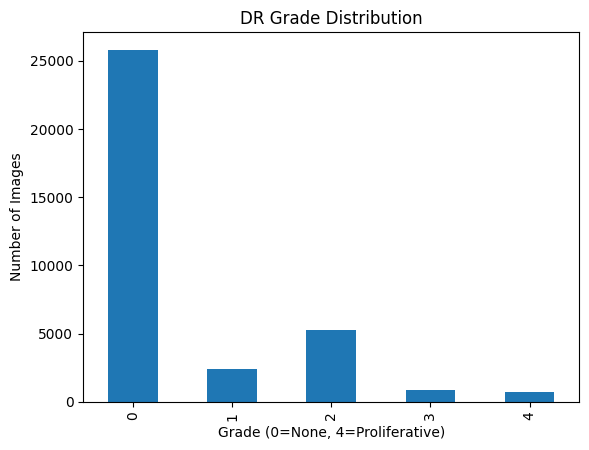

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load Labels
df = pd.read_csv('../data/trainLabels.csv')
print(df.head())

print(df['level'].value_counts().sort_index())

# Visualize class distribution
df['level'].value_counts().sort_index().plot(kind='bar')
plt.title('DR Grade Distribution')
plt.xlabel('Grade (0=None, 4=Proliferative)')
plt.ylabel('Number of Images')
plt.show()

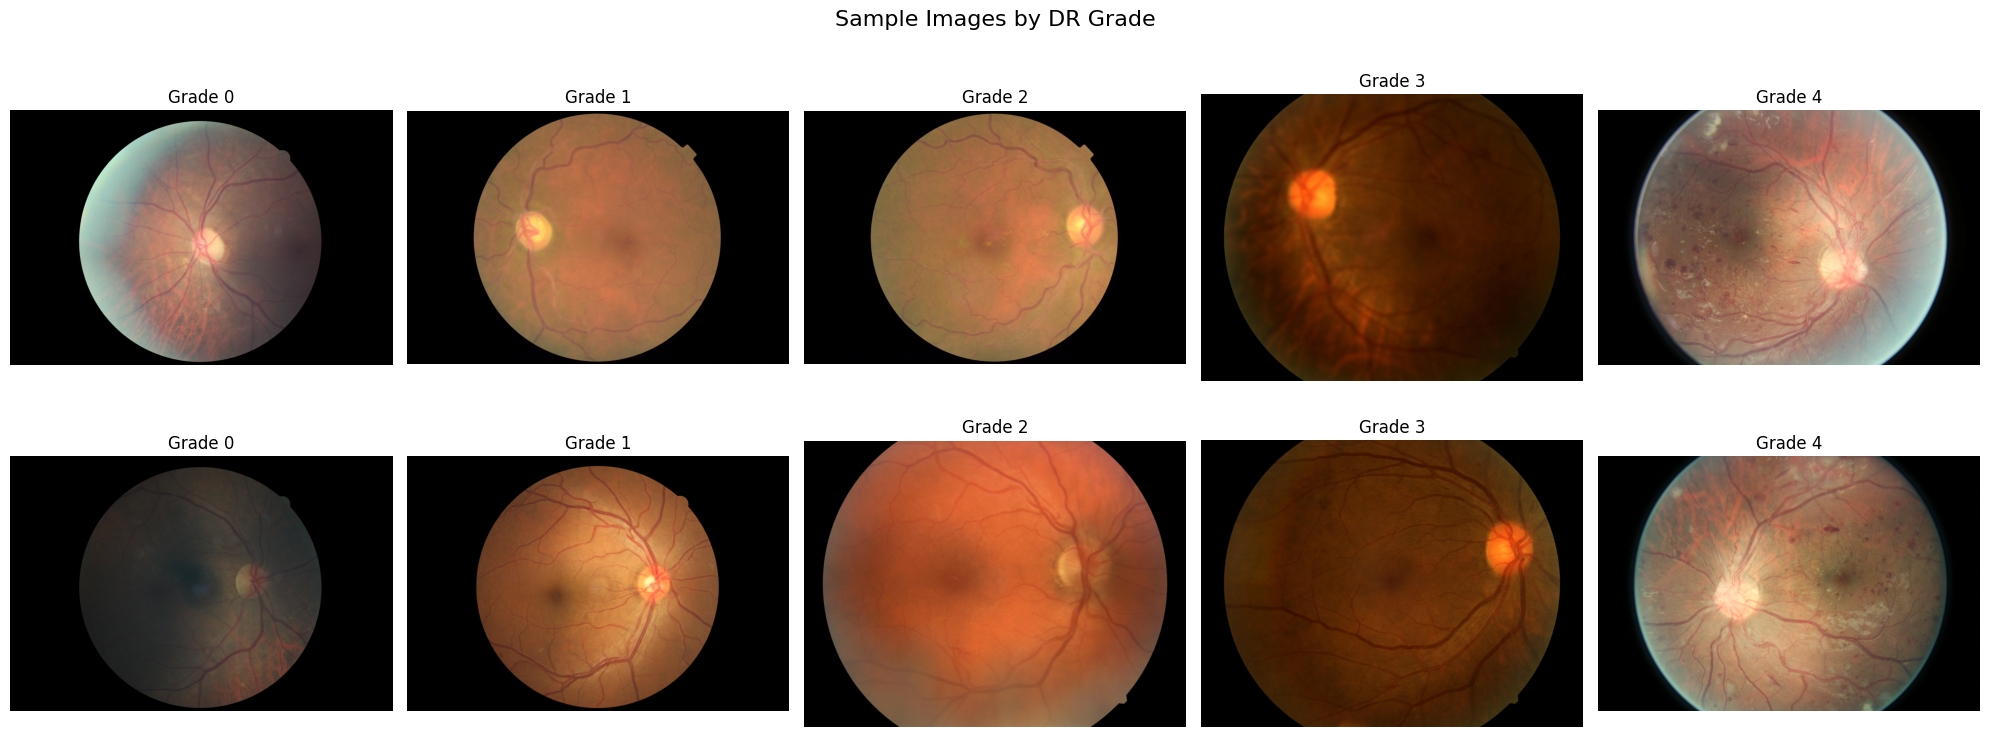

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Show one example of each grade
for grade in range(5):
    samples = df[df['level'] == grade]['image'].values[:2]
    for i, img_name in enumerate(samples):
        img_path = f'../data/train/{img_name}.jpeg'
        img = Image.open(img_path)
        axes[i][grade].imshow(img)
        axes[i][grade].set_title(f'Grade {grade}')
        axes[i][grade].axis('off')

plt.suptitle('Sample Images by DR Grade', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
import sys
import os
import torch

# This allows the notebook to "see" model.py in the folder above
sys.path.append(os.path.abspath('..'))

try:
    from model import DRClassifier
    print("✅ Successfully imported DRClassifier from model.py")
except ImportError:
    print("❌ Could not import model.py. Make sure your notebook is in the 'notebooks' folder and model.py is in 'inference-engine'")

# --- RUN ARCHITECTURE TEST ---

# 1. Instantiate the model
model = DRClassifier(num_classes=5)

# 2. Create dummy input (Batch Size 1, 3 Channels, 224x224 Resolution)
dummy_input = torch.randn(1, 3, 224, 224)

# 3. Pass through model
output = model(dummy_input)

# 4. Verify Shapes
print(f'\nInput shape:  {dummy_input.shape}')
print(f'Output shape: {output.shape}')  # Expected: torch.Size([1, 5])
print(f'Output (raw logits):\n{output.detach().numpy()}') # Detach removes it from gradient graph for printing

# 5. Verify Freezing (The most important part!)
print("\nChecking Parameter Freezing...")
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f'Trainable params: {trainable:,}')
print(f'Total params:     {total:,}')
print(f'Percent Trainable: {100 * trainable / total:.2f}%')

# If Percent Trainable is around ~4-10%, your freezing logic works!
# If it's 100%, your freezing logic failed.

✅ Successfully imported DRClassifier from model.py

Input shape:  torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 5])
Output (raw logits):
[[-0.34654784 -0.16769993 -0.179824   -0.17933792 -0.01033474]]

Checking Parameter Freezing...
Trainable params: 16,016,389
Total params:     24,559,685
Percent Trainable: 65.21%
